# Notebook 3: Model Interpretability and Business Actionability

Notebook 1 established the churn business problem and explored the main patterns in the customer base.

Notebook 2 performed and explained the predictive workflow: preprocessing, model comparison, XGBoost tuning, threshold selection and final evaluation.

This third notebook focuses on interpretability and business actionability. The goal is to understand how the trained model behaves, explain individual predictions and translate churn risk signals into operational retention recommendations.

## 1. Why Interpretability Matters in Churn Modeling

A high-performing churn model is useful, but it is not enough on its own. Retention teams need more than a probability score: they need to understand why a customer is being flagged and what kind of action might be relevant.

For this project, interpretability helps answer three practical questions:

- What appears to drive churn risk overall?
- What drives the risk score for an individual customer?
- Which of those drivers are actionable from a retention perspective?

The goal is not to claim causality. The goal is to make model outputs easier to trust, prioritize and discuss with business stakeholders.

## 2. Imports and Setup

The notebook uses the existing project functions for data preparation, threshold selection, SHAP computation, result assembly and recommendation generation. Notebook-local code is only used for plotting and compact display.

In [16]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap

from IPython.display import display

from src.telco_churn.preprocess import (
    load_telco_data,
    split_features_target,
    split_train_test,
)

from src.telco_churn.evaluate import (
    find_best_threshold,
    evaluate_classifier,
)

from src.telco_churn.recommend import (
    build_results_frame,
    compute_shap_values,
    attach_recommendations,
)

from src.telco_churn.config import (
    MODEL_PATH,
    FIGURES_DIR,
    LOW_RISK_THRESHOLD,
    HIGH_RISK_THRESHOLD,
    ACTIONABLE_INTERVENTIONS
)

from src.telco_churn.visualization import (
    set_theme,
    bar_plot,
    hist_plot,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)

set_theme()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

shap.initjs()

## 3. Load Data, Rebuild the Split and Load the Model

The split is recreated using the same project utilities as Notebook 2. This keeps the train/test split consistent with the model evaluation workflow.

The model is loaded from disk rather than retrained. This notebook is an interpretability layer on top of the saved model.

In [17]:
df = load_telco_data()
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = split_train_test(X, y)

model = joblib.load(MODEL_PATH)

print(f"Data loaded: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
print(f"Train set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Model loaded")

Data loaded: 7,043 rows and 21 columns
Train set: 5,634 rows
Test set: 1,409 rows
Model loaded


## 4. Prediction Outputs and Risk Segmentation

The model outputs customer-level churn probabilities rather than only binary predictions. This is more useful operationally, because retention teams typically need prioritization, not just a yes/no label.

The classification threshold is still optimized on the training set only. The test set is used here to examine prediction outputs and derive a practical risk segmentation.

In [4]:
best_threshold = find_best_threshold(model, X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

metrics, predictions = evaluate_classifier(
    model,
    X_test,
    y_test,
    threshold=best_threshold,
)

print(f"Optimized classification threshold: {best_threshold:.4f}")
print(f"ROC AUC on test set: {metrics['roc_auc']:.4f}")
print(f"Average Precision on test set: {metrics['average_precision']:.4f}")

Optimized classification threshold: 0.5606
ROC AUC on test set: 0.8531
Average Precision on test set: 0.6618


Before defining operational risk bands, it is useful to inspect the distribution of predicted churn probabilities on the test set. This helps assess whether the model produces a meaningful spread of scores and provides the basis for the segmentation cutoffs.

Figure saved.


<Axes: title={'center': 'Distribution of predicted churn probabilities'}, xlabel='Predicted churn probability', ylabel='Number of customers'>

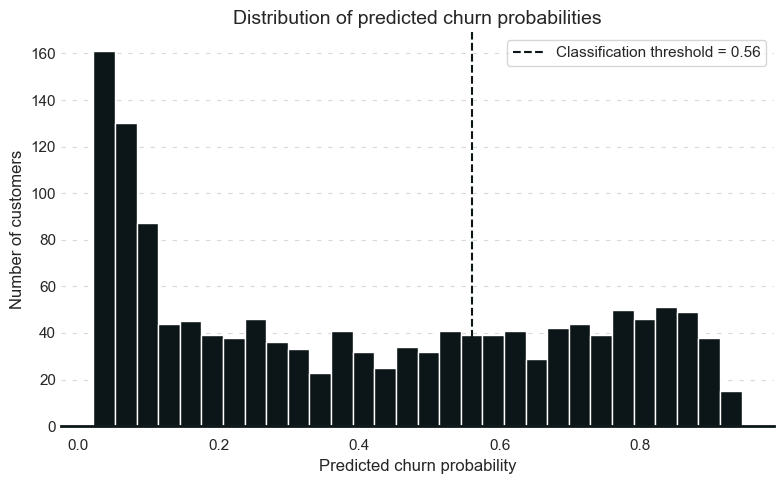

In [5]:
proba_df = pd.DataFrame({"churn_proba": y_proba})

hist_plot(
    data=proba_df,
    column="churn_proba",
    bins=30,
    title="Distribution of predicted churn probabilities",
    xlabel="Predicted churn probability",
    ylabel="Number of customers",
    vlines=[
        {
            "x": best_threshold,
            "label": f"Classification threshold = {best_threshold:.2f}",
            "linestyle": "--",
        }
    ],
    save_path=FIGURES_DIR / "predicted_probability_distribution.png",
)

The distribution shows that the model produces a broad range of predicted probabilities rather than concentrating customers around a single score. This makes it useful to move beyond a binary prediction and define three operational bands:

- **Low risk** for customers with clearly low predicted probability (p < 0.30)
- **Moderate risk** for customers in an intermediate and more ambiguous zone (0.30 &le; p < 0.60)
- **High risk** for customers with clearly elevated predicted probability (p &ge; 0.60)

The segmentation thresholds are chosen with this distribution in mind. Their role is not to replace the classification threshold, but to translate continuous scores into a more practical prioritization framework.

In [6]:
results = build_results_frame(X_test, y_proba, y_pred)

print(f"Low-risk threshold: {LOW_RISK_THRESHOLD:.2f}")
print(f"High-risk threshold: {HIGH_RISK_THRESHOLD:.2f}")

results[["churn_proba", "churn_prediction", "risk_segment"]].head(10)

Low-risk threshold: 0.30
High-risk threshold: 0.60


,churn_proba,churn_prediction,risk_segment
0,0.0399,0,Low risk
1,0.6806,1,High risk
2,0.9345,1,High risk
3,0.3617,0,Moderate risk
4,0.1097,0,Low risk
5,0.6268,1,High risk
6,0.8240,1,High risk
7,0.5125,0,Moderate risk
8,0.9011,1,High risk
9,0.7316,1,High risk


In [7]:
segment_summary = (
    results["risk_segment"]
    .value_counts()
    .reindex(["Low risk", "Moderate risk", "High risk"])
    .rename_axis("Risk segment")
    .reset_index(name="Number of customers")
)

segment_summary["Share of customers"] = (
    segment_summary["Number of customers"] / len(results)
)

segment_summary

,Risk segment,Number of customers,Share of customers
0,Low risk,627,0.4450
1,Moderate risk,328,0.2328
2,High risk,454,0.3222


Figure saved.


<Axes: title={'center': 'Customer distribution across risk segments'}>

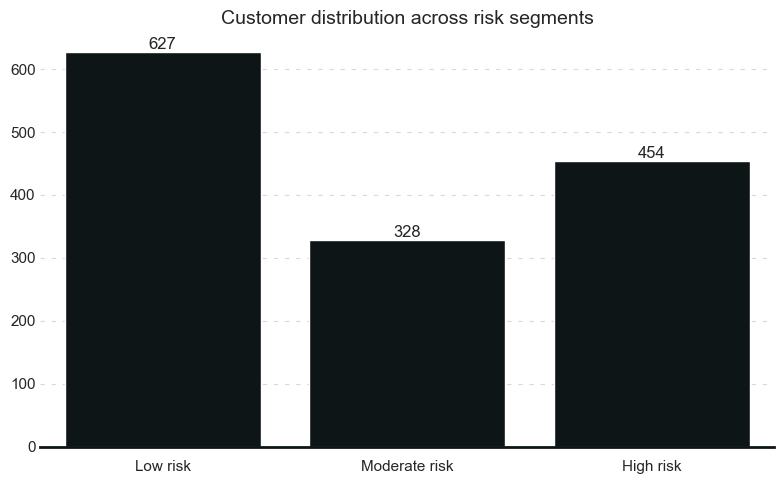

In [8]:
bar_plot(
    data=results,
    column="risk_segment",
    title="Customer distribution across risk segments",
    normalize=False,
    order=["Low risk", "Moderate risk", "High risk"],
    save_path=FIGURES_DIR / "risk_segment_counts.png"
)

This segmentation provides a more operational reading of the model outputs. High-risk customers form the most urgent intervention pool, moderate-risk customers correspond to a more uncertain middle zone and low-risk customers are less likely to justify immediate action.

In practice, this makes the model easier to use for retention planning: instead of relying only on a binary prediction, teams can prioritize customers according to the intensity and urgency of the risk signal. The segmentation could also support different types of interventions depending on the risk level, although this notebook does not yet implement segment-specific recommendation rules. This matters because retention resources are limited.

## 5. Prepare SHAP Inputs

SHAP values decompose a model prediction into feature-level contributions. For each customer, they estimate which transformed features pushed the prediction higher or lower relative to the model baseline.

The project helper handles the internal XGBoost pipeline structure, including the `preprocessor` step and the recovery of transformed feature names after one-hot encoding.

In [9]:
numerical_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

shap_values, transformed_df, feature_names = compute_shap_values(
    model,
    X_test,
    categorical_cols,
    numerical_cols,
)

print(f"Transformed SHAP matrix: {transformed_df.shape}")

Numerical columns: 4
Categorical columns: 15
Transformed SHAP matrix: (1409, 45)


## 6. Global Interpretability

### 6.1. SHAP Summary Plot

The SHAP summary plot shows which features contribute most to model predictions across the test set. It also gives a directional view: points to the right increase predicted churn risk, while points to the left decrease it.

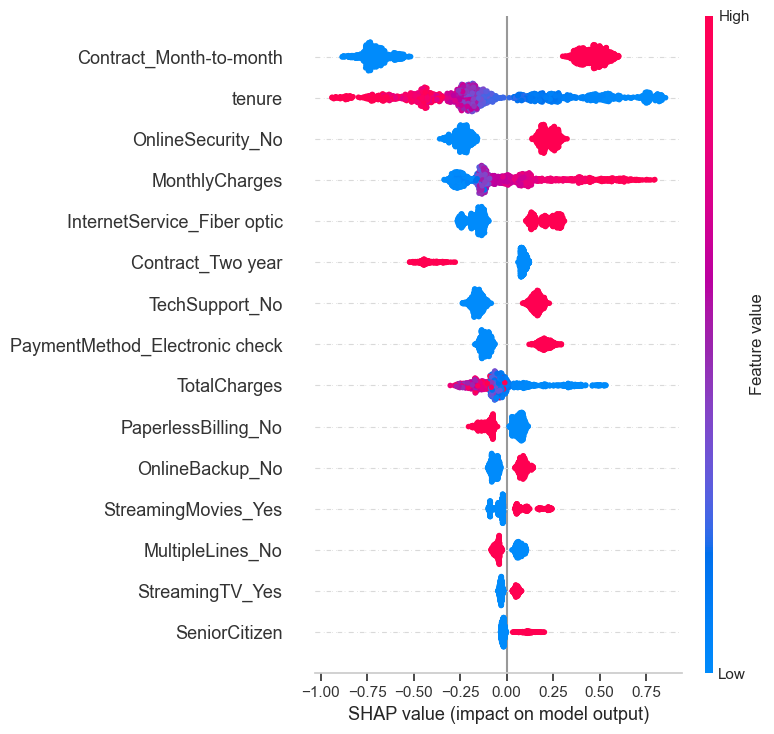

Figure saved.


In [10]:
summary_plot_path = FIGURES_DIR / "shap_summary_beeswarm.png"

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    transformed_df,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig(summary_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved.")

The SHAP summary plot shows that churn is not driven by a single variable, but by a coherent profile of low-commitment customers. The strongest positive contributions to churn come from month-to-month contracts, short tenure, higher monthly charges, fiber optic internet, and the absence of protective or support-related services such as online security and tech support.

Taken together, these features point to a specific customer archetype: relatively recent subscribers who pay more each month, remain on flexible contracts and have not anchored their relationship with the company through complementary support services. In contrast, longer tenure and two-year contracts push predictions away from churn, suggesting that retention is strongly associated with commitment and customer maturity.

An important nuance is that monthly charges and total charges move in opposite directions: high monthly charges increase churn risk, while high total charges tend to reduce it. This pattern is consistent with the idea that customers who are expensive on a monthly basis but have accumulated little total spending are often newer and less established, whereas high total charges mostly reflect long-standing customers. Overall, the model captures churn as a combination of contract flexibility, limited attachment, and higher exposure to competitive switching.

### 6.2. Mean Absolute SHAP Importance

The bar plot ranks features by average absolute SHAP value. The two plots are complementary: the bar chart shows which variables matter most on average, while the summary plot reveals the direction of their effect and the heterogeneity of their impact across customers.

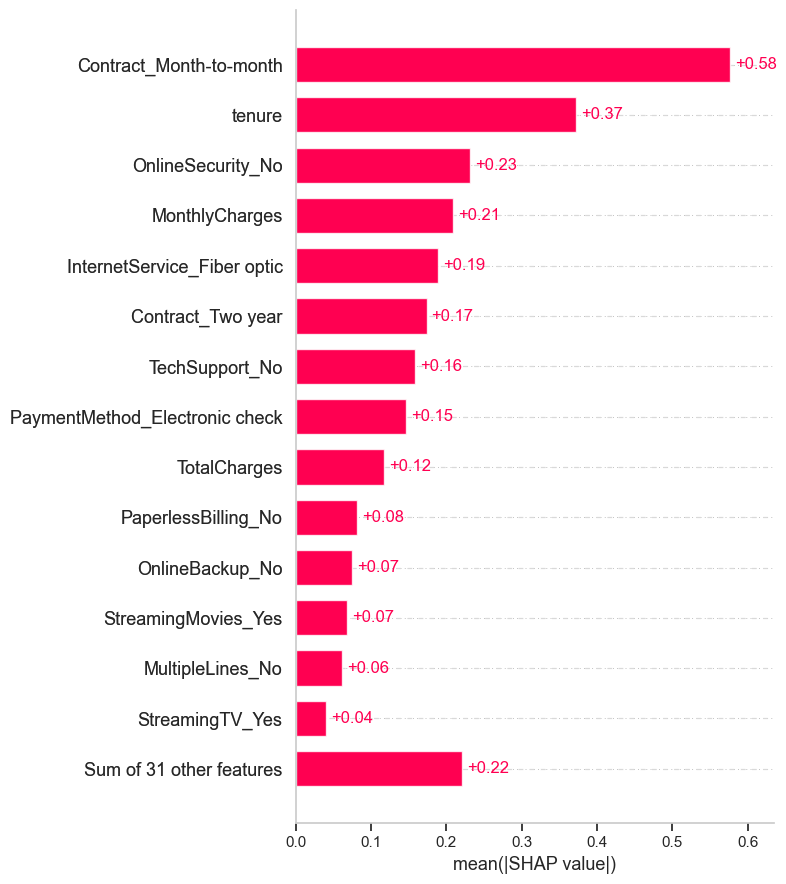

Figure saved.


In [11]:
bar_plot_path = FIGURES_DIR / "shap_mean_absolute_importance.png"

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(bar_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved.")

The feature importance plot helps clarify the structure of the model’s decision process. Contract type clearly dominates: month-to-month contracts are by far the most influential feature, well ahead of the others. Tenure comes next, confirming that customer stability is a central dimension of churn prediction.

Beyond these two core drivers, the remaining important variables are highly consistent with the same underlying story. The absence of online security or tech support, fiber optic internet, electronic check payment and higher monthly charges all point toward a more volatile and less anchored customer base. By contrast, variables associated with longer commitment, such as two-year contracts and higher accumulated charges, contribute to lower churn risk.

What stands out is not just the ranking of individual variables, but the coherence of the group. The model is not simply learning that “price” or “product type” matters in isolation; it is identifying a broader pattern of customers who combine flexibility, relatively low attachment, and fewer retention-oriented services. This makes the model’s behavior easier to interpret from a business perspective and suggests that churn risk is concentrated in identifiable customer profiles rather than being randomly distributed across the base.

## 7. Customer-Level Interpretability

Global SHAP patterns are useful, but they do not show how churn risk is assembled for a specific customer. Looking at one representative example per risk segment makes the model’s behavior more concrete and shows how similar global drivers can combine differently at the individual level.

In [12]:
def pick_example_index(results_df, segment):
    segment_rows = results_df[results_df["risk_segment"] == segment]
    if segment_rows.empty:
        return None
    if segment == "High risk":
        return segment_rows["churn_proba"].idxmax()
    if segment == "Low risk":
        return segment_rows["churn_proba"].idxmin()
    midpoint = (LOW_RISK_THRESHOLD + HIGH_RISK_THRESHOLD) / 2
    return (segment_rows["churn_proba"] - midpoint).abs().idxmin()


example_indices = {
    "High risk": pick_example_index(results, "High risk"),
    "Moderate risk": pick_example_index(results, "Moderate risk"),
    "Low risk": pick_example_index(results, "Low risk"),
}

example_indices

{'High risk': np.int64(307),
 'Moderate risk': np.int64(1062),
 'Low risk': np.int64(1285)}

In [13]:
def show_customer_example(segment_name, example_indices, results, shap_values, figures_dir, max_display=10):
    idx = example_indices.get(segment_name)

    if idx is None:
        print(f"No {segment_name.lower()} customer is available in the current test split.")
        return

    print(f"Predicted churn probability: {results.loc[idx, 'churn_proba']:.4f}")
    print(f"Risk segment: {results.loc[idx, 'risk_segment']}")

    safe_name = segment_name.lower().replace(" ", "_")
    waterfall_path = figures_dir / f"shap_waterfall_{safe_name}.png"

    shap.plots.waterfall(shap_values[idx], max_display=max_display, show=False)
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved.")


HIGH RISK
Predicted churn probability: 0.9445
Risk segment: High risk


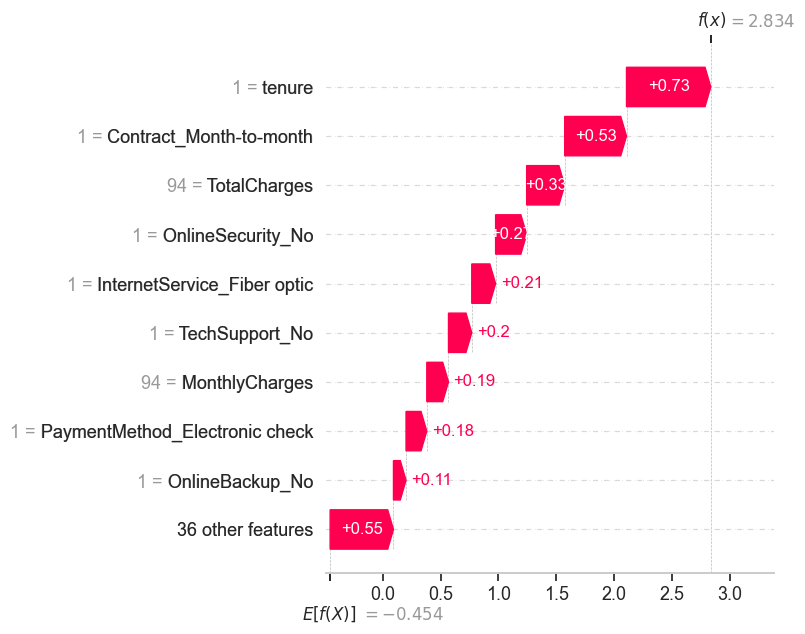

Figure saved.

MODERATE RISK
Predicted churn probability: 0.4485
Risk segment: Moderate risk


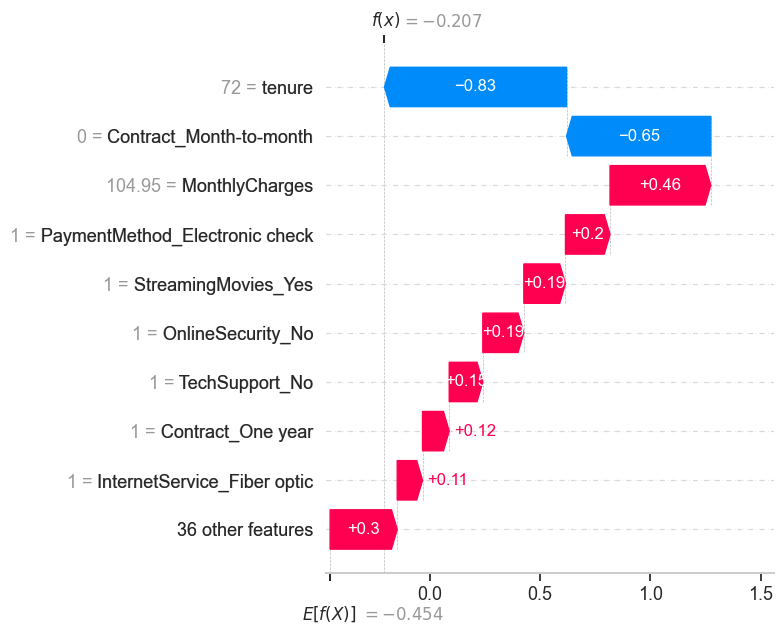

Figure saved.

LOW RISK
Predicted churn probability: 0.0219
Risk segment: Low risk


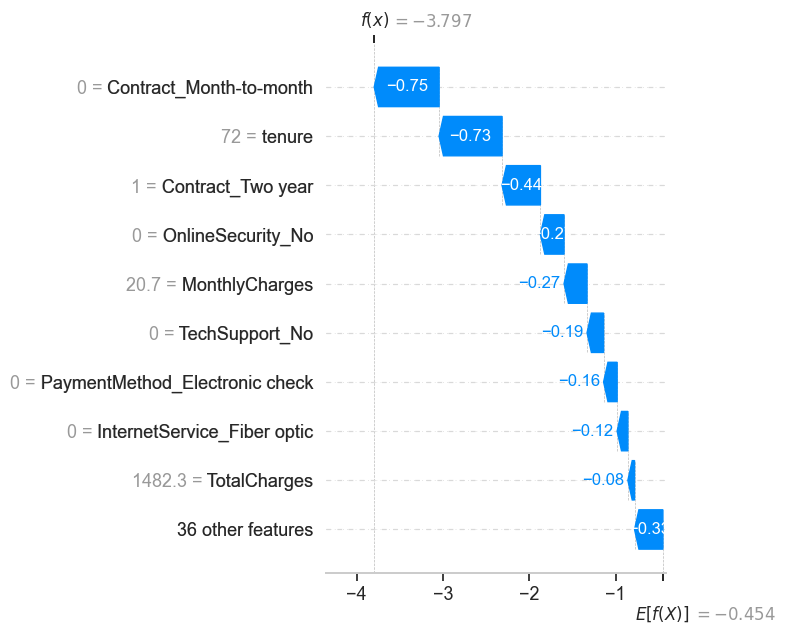

Figure saved.


In [14]:
for segment in ["High risk", "Moderate risk", "Low risk"]:
    print("\n" + "=" * 60)
    print(segment.upper())
    print("=" * 60)

    show_customer_example(
        segment_name=segment,
        example_indices=example_indices,
        results=results,
        shap_values=shap_values,
        figures_dir=FIGURES_DIR,
    )

These examples complement the global analysis by showing how churn risk is built customer by customer. The high-risk case illustrates the accumulation of unfavorable signals, the moderate-risk case shows a more mixed profile, and the low-risk case highlights the factors that keep a customer outside the priority retention pool.

## 8. From Explanation to Action

The final step is to turn model explanations into operational suggestions. The project recommendation logic uses SHAP values at the customer level to identify the main actionable drivers of churn and map them to predefined intervention ideas.

More precisely, for each customer, the system keeps only the features that both increase churn risk (positive SHAP contribution) and belong to a predefined list of actionable levers. It then returns the top two corresponding interventions. The goal is not to claim that these actions will necessarily reduce churn, but to provide a structured starting point for retention review.

In [15]:
action_library = (
    pd.DataFrame(
        ACTIONABLE_INTERVENTIONS.items(),
        columns=["Actionable driver", "Associated intervention"]
    )
)

action_library

,Actionable driver,Associated intervention
0,Contract_Month-to-month,Offer a discount on a one-year or two-year contract.
1,OnlineSecurity_No,Bundle online security for three free months.
2,TechSupport_No,Offer discounted technical support.
3,MonthlyCharges,Propose a cheaper plan or bundle.
4,InternetService_Fiber optic,Check service quality and perceived value of fiber.
5,PaperlessBilling_No,Promote paperless billing with an incentive.
6,OnlineBackup_No,Offer online backup at a discounted price.


This intervention library defines the set of churn drivers that are treated as operationally actionable in the project. Any positive SHAP contributor outside this list may still be predictive, but it will not be translated into a recommendation.

In [25]:
enriched_results = attach_recommendations(results, shap_values, feature_names)

enriched_results["top_actionable_drivers"] = enriched_results["actionable_drivers"].apply(
    lambda items: ", ".join(items) if items else "No actionable driver identified"
)

enriched_results["proposed_interventions"] = enriched_results["interventions"].apply(
    lambda items: " | ".join(items)
)

action_table = (
    enriched_results
    .loc[:, ["churn_proba", "risk_segment", "top_actionable_drivers", "proposed_interventions"]]
    .head(10)
)

action_table

,churn_proba,risk_segment,top_actionable_drivers,proposed_interventions
0,0.0399,Low risk,No actionable driver identified,No specific interventions identified.
1,0.6806,High risk,"Contract_Month-to-month, OnlineSecurity_No",Offer a discount on a one-year or two-year contract. | Bundle online security for three free months.
2,0.9345,High risk,"Contract_Month-to-month, OnlineSecurity_No",Offer a discount on a one-year or two-year contract. | Bundle online security for three free months.
3,0.3617,Moderate risk,"Contract_Month-to-month, InternetService_Fiber optic",Offer a discount on a one-year or two-year contract. | Check service quality and perceived value of fiber.
4,0.1097,Low risk,OnlineSecurity_No,Bundle online security for three free months.
5,0.6268,High risk,"Contract_Month-to-month, OnlineSecurity_No",Offer a discount on a one-year or two-year contract. | Bundle online security for three free months.
6,0.8240,High risk,"Contract_Month-to-month, InternetService_Fiber optic",Offer a discount on a one-year or two-year contract. | Check service quality and perceived value of fiber.
7,0.5125,Moderate risk,"MonthlyCharges, OnlineSecurity_No",Propose a cheaper plan or bundle. | Bundle online security for three free months.
8,0.9011,High risk,"Contract_Month-to-month, OnlineSecurity_No",Offer a discount on a one-year or two-year contract. | Bundle online security for three free months.
9,0.7316,High risk,"Contract_Month-to-month, OnlineSecurity_No",Offer a discount on a one-year or two-year contract. | Bundle online security for three free months.


This table is the final bridge between model interpretation and business use. For each customer, it combines a risk level, the main actionable SHAP drivers, and the intervention ideas associated with those drivers.

These suggestions should be treated as decision support rather than automated prescriptions. A feature can be predictive without being fully controllable, and a plausible intervention is not the same as a proven causal remedy. In practice, such recommendations would still need to be reviewed against business constraints and, ideally, validated through experimentation.

## 9. Conclusion

This notebook shows that a churn model becomes substantially more useful once its predictions are made interpretable and operationally readable. Global SHAP analysis identifies the dominant patterns behind churn, local explanations show how these factors interact at the customer level, and risk segmentation converts raw probabilities into a practical prioritization framework.

The key contribution is not to claim causal certainty, but to move from a black-box score to a structured decision aid. In that sense, interpretability is valuable not only for trust, but for turning prediction into a more actionable retention workflow.